In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Environment ready!
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1


In [ ]:
df = pd.read_csv("/content/user_login_analysis1 (1).csv")
df.head()

,user_id,login_time,device_type,login_status,location
0,user_0972,2025-01-02 17:25:00,tablet,success,Paris
1,user_0202,2025-01-02 23:15:00,mobile,success,New York
2,user_0497,2025-01-03 04:44:00,tablet,success,Sydney
3,user_0447,2025-01-03 21:32:00,tablet,success,Paris
4,user_0551,2025-01-04 09:23:00,tablet,success,Sydney


In [ ]:
print("Rows, columns:" , df.shape)
df.info()

Rows, columns: (1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       1000 non-null   object
 1   login_time    1000 non-null   object
 2   device_type   1000 non-null   object
 3   login_status  1000 non-null   object
 4   location      1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB


In [ ]:
df.describe()

,user_id,login_time,device_type,login_status,location
count,1000,1000,1000,1000,1000
unique,1000,999,3,2,6
top,user_0459,2025-12-02 04:54:00,tablet,success,Sydney
freq,1,2,354,898,193


In [ ]:
grouped_df = df.groupby(['login_status', 'device_type', 'login_time']).size().reset_index(name='count')
print("Grouped by Login Status, Device Type, and Login Time:")
display(grouped_df)

Grouped by Login Status, Device Type, and Login Time:


,login_status,device_type,login_time,count
0,failure,desktop,2025-01-08 15:48:00,1
1,failure,desktop,2025-01-10 00:39:00,1
2,failure,desktop,2025-02-04 22:33:00,1
3,failure,desktop,2025-02-25 08:34:00,1
4,failure,desktop,2025-02-27 11:12:00,1
...,...,...,...,...
995,success,tablet,2025-12-21 20:04:00,1
996,success,tablet,2025-12-21 20:16:00,1
997,success,tablet,2025-12-25 05:54:00,1
998,success,tablet,2025-12-25 16:30:00,1


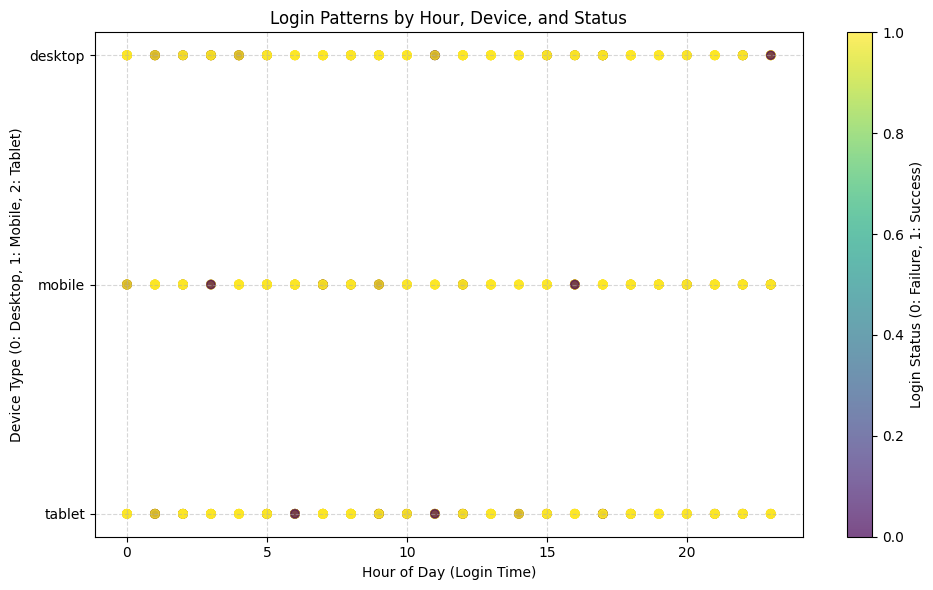

In [ ]:
df['login_time'] = pd.to_datetime(df['login_time'])

df['login_hour'] = df['login_time'].dt.hour

device_type_mapping = {device: i for i, device in enumerate(df['device_type'].unique())}
df['device_type_numeric'] = df['device_type'].map(device_type_mapping)

login_status_mapping = {'failure': 0, 'success': 1}
df['login_status_numeric'] = df['login_status'].map(login_status_mapping)

plt.figure(figsize=(10, 6))
plt.scatter(df["login_hour"], df["device_type_numeric"], c=df["login_status_numeric"], cmap='viridis', alpha=0.7)
plt.xlabel("Hour of Day (Login Time)")
plt.ylabel("Device Type (0: Desktop, 1: Mobile, 2: Tablet)")
plt.title("Login Patterns by Hour, Device, and Status")
plt.colorbar(label='Login Status (0: Failure, 1: Success)')
plt.yticks(list(device_type_mapping.values()), list(device_type_mapping.keys()))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Define features (X) and target (y)
X = df[['login_hour', 'device_type_numeric']]
X = pd.concat([X, pd.get_dummies(df['location'], prefix='location', drop_first=True)], axis=1)
y = df['login_status_numeric']

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

# Initialize and train the Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

X shape: (1000, 7)
y shape: (1000,)
Training rows: 800
Testing rows : 200
Model trained!


In [ ]:
prediction = model.predict(X_test)

In [ ]:
print(prediction)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
print(X_test)

     login_hour  device_type_numeric  ...  location_Sydney  location_Tokyo
168           2                    1  ...            False            True
918          12                    1  ...             True           False
270          23                    2  ...            False           False
754           6                    1  ...            False           False
215          21                    1  ...            False           False
..          ...                  ...  ...              ...             ...
389          15                    1  ...            False           False
160          12                    2  ...            False           False
711           4                    2  ...             True           False
52            2                    0  ...            False            True
219           0                    1  ...             True           False

[200 rows x 7 columns]


In [ ]:
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 90.00%


[Text(0.5, 0.875, 'login_hour <= 6.5\ngini = 0.184\nsamples = 800\nvalue = [82, 718]\nclass = Success'),
 Text(0.25, 0.625, 'location_Sydney <= 0.5\ngini = 0.234\nsamples = 237\nvalue = [32.0, 205.0]\nclass = Success'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'login_hour <= 0.5\ngini = 0.258\nsamples = 191\nvalue = [29, 162]\nclass = Success'),
 Text(0.0625, 0.125, 'gini = 0.165\nsamples = 33\nvalue = [3, 30]\nclass = Success'),
 Text(0.1875, 0.125, 'gini = 0.275\nsamples = 158\nvalue = [26, 132]\nclass = Success'),
 Text(0.375, 0.375, 'device_type_numeric <= 0.5\ngini = 0.122\nsamples = 46\nvalue = [3, 43]\nclass = Success'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]\nclass = Success'),
 Text(0.4375, 0.125, 'gini = 0.191\nsamples = 28\nvalue = [3, 25]\nclass = Success'),
 Text(0.75, 0.625, 'location_New York <= 0.5\ngini = 0.162\nsamples = 563\nvalue = [50, 513]\nclass = Success'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'location_Sydney <= 0

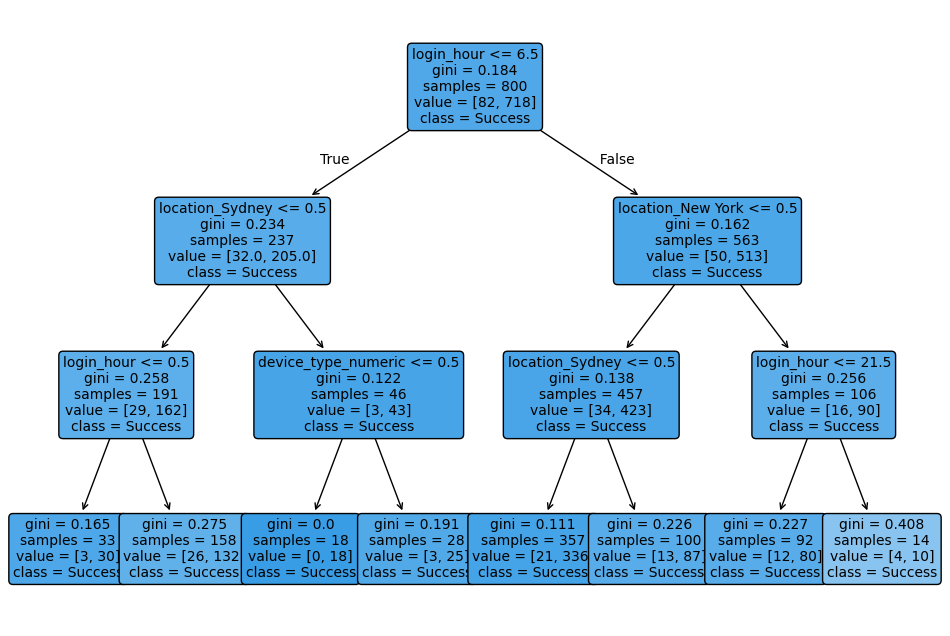

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Failure', 'Success'],
          filled=True,
          rounded=True,
          fontsize=10)